<a href="https://colab.research.google.com/github/Sanvi2811/Fair-Score/blob/main/Fair_Score.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import userdata
token = userdata.get('KAGGLE_API_TOKEN')
print("Token loaded:", token[:8] + "..." if token else "NOT FOUND")

Token loaded: KGAT_e9d...


In [ ]:
import os
from google.colab import userdata

os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!pip install kaggle -q
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False  
https://www.kaggle.com/competitions/arc-prize-2026-arc-agi-3                  2026-11-02

In [ ]:
data_dir = '/content/drive/MyDrive/glass-box-credit/data'
import os
os.makedirs(data_dir, exist_ok=True)

!kaggle competitions download -c home-credit-default-risk -f application_train.csv -p {data_dir}
!kaggle competitions download -c home-credit-default-risk -f bureau.csv -p {data_dir}
!unzip -o {data_dir}/'*.zip' -d {data_dir}

100% 36.1M/36.1M [00:00<00:00, 138MB/s]

100% 36.8M/36.8M [00:00<00:00, 146MB/s]

Archive:  /content/drive/MyDrive/glass-box-credit/data/application_train.csv.zip
  inflating: /content/drive/MyDrive/glass-box-credit/data/application_train.csv  

Archive:  /content/drive/MyDrive/glass-box-credit/data/bureau.csv.zip
  inflating: /content/drive/MyDrive/glass-box-credit/data/bureau.csv  

2 archives were successfully processed.


In [ ]:
import pandas as pd
df = pd.read_csv(f'{data_dir}/application_train.csv')
print(df.shape)

(307511, 122)


In [ ]:
print(df['TARGET'].value_counts(normalize=True))

TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [ ]:
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing > 0].head(20))

COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
FLOORSMIN_MODE              0.678486
FLOORSMIN_AVG               0.678486
FLOORSMIN_MEDI              0.678486
YEARS_BUILD_AVG             0.664978
YEARS_BUILD_MODE            0.664978
YEARS_BUILD_MEDI            0.664978
OWN_CAR_AGE                 0.659908
LANDAREA_MEDI               0.593767
LANDAREA_AVG                0.593767
LANDAREA_MODE               0.593767
dtype: float64


In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()
print(f"{len(num_cols)} numeric, {len(cat_cols)} categorical")

106 numeric, 16 categorical


In [ ]:
print(df['CODE_GENDER'].value_counts())
print(df.groupby('CODE_GENDER')['TARGET'].mean())

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
CODE_GENDER
F      0.069993
M      0.101419
XNA    0.000000
Name: TARGET, dtype: float64


In [ ]:
df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365
df['AGE_BUCKET'] = pd.cut(df['AGE_YEARS'], bins=[20,30,40,50,60,70])
print(df.groupby('AGE_BUCKET')['TARGET'].mean())

AGE_BUCKET
(20, 30]    0.114569
(30, 40]    0.095835
(40, 50]    0.076508
(50, 60]    0.061297
(60, 70]    0.049214
Name: TARGET, dtype: float64


/tmp/ipykernel_1911/4174692234.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby('AGE_BUCKET')['TARGET'].mean())


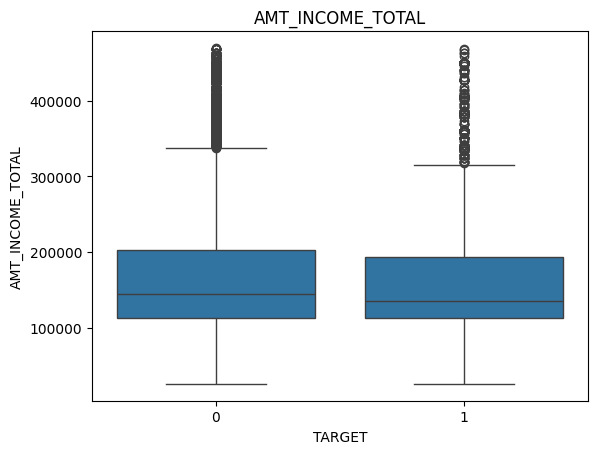

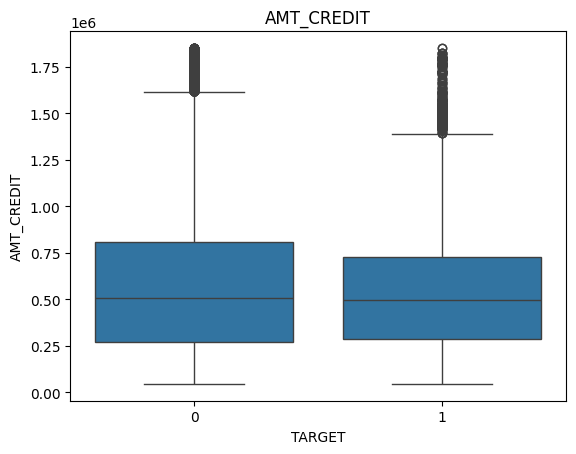

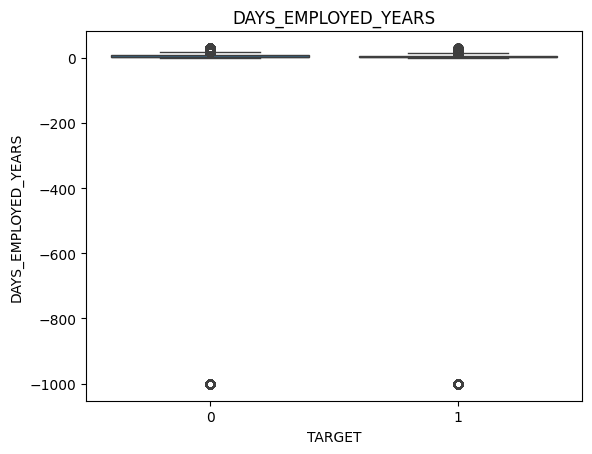

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df['DAYS_EMPLOYED_YEARS'] = -df['DAYS_EMPLOYED'] / 365  # watch for a weird outlier spike here

for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_EMPLOYED_YEARS']:
    plt.figure()
    sns.boxplot(x='TARGET', y=col, data=df[df[col] < df[col].quantile(0.99)])
    plt.title(col)
    plt.show()

In [ ]:
bureau = pd.read_csv(f'{data_dir}/bureau.csv')
print(bureau.shape)
bureau.head()

(1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


In [ ]:
# how many past credit records per applicant?
print(bureau.groupby('SK_ID_CURR').size().describe())

# what does credit status look like?
print(bureau['CREDIT_ACTIVE'].value_counts())

count    305811.000000
mean          5.612709
std           4.430354
min           1.000000
25%           2.000000
50%           4.000000
75%           8.000000
max         116.000000
dtype: float64
CREDIT_ACTIVE
Closed      1079273
Active       630607
Sold           6527
Bad debt         21
Name: count, dtype: int64


In [ ]:
#count of past loans, overdue behavior, and credit amounts
bureau_agg = bureau.groupby('SK_ID_CURR').agg(
    BUREAU_LOAN_COUNT=('SK_ID_BUREAU', 'count'),
    BUREAU_DAYS_CREDIT_MEAN=('DAYS_CREDIT', 'mean'),
    BUREAU_CREDIT_DAY_OVERDUE_MAX=('CREDIT_DAY_OVERDUE', 'max'),
    BUREAU_CREDIT_DAY_OVERDUE_MEAN=('CREDIT_DAY_OVERDUE', 'mean'),
    BUREAU_AMT_CREDIT_SUM_MEAN=('AMT_CREDIT_SUM', 'mean'),
    BUREAU_AMT_CREDIT_SUM_DEBT_MEAN=('AMT_CREDIT_SUM_DEBT', 'mean'),
    BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN=('AMT_CREDIT_SUM_OVERDUE', 'mean'),
    BUREAU_CNT_CREDIT_PROLONG_SUM=('CNT_CREDIT_PROLONG', 'sum'),
).reset_index()

# a derived feature: % of past loans still active
active_pct = bureau.groupby('SK_ID_CURR')['CREDIT_ACTIVE'].apply(
    lambda x: (x == 'Active').mean()
).reset_index(name='BUREAU_PCT_ACTIVE_LOANS')

bureau_agg = bureau_agg.merge(active_pct, on='SK_ID_CURR', how='left')

print(bureau_agg.shape)
bureau_agg.head()

(305811, 10)


,SK_ID_CURR,BUREAU_LOAN_COUNT,BUREAU_DAYS_CREDIT_MEAN,BUREAU_CREDIT_DAY_OVERDUE_MAX,BUREAU_CREDIT_DAY_OVERDUE_MEAN,BUREAU_AMT_CREDIT_SUM_MEAN,BUREAU_AMT_CREDIT_SUM_DEBT_MEAN,BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN,BUREAU_CNT_CREDIT_PROLONG_SUM,BUREAU_PCT_ACTIVE_LOANS
0,100001,7,-735.000000,0,0.0,207623.571429,85240.928571,0.0,0,0.428571
1,100002,8,-874.000000,0,0.0,108131.945625,49156.200000,0.0,0,0.250000
2,100003,4,-1400.750000,0,0.0,254350.125000,0.000000,0.0,0,0.250000
3,100004,2,-867.000000,0,0.0,94518.900000,0.000000,0.0,0,0.000000
4,100005,3,-190.666667,0,0.0,219042.000000,189469.500000,0.0,0,0.666667


In [ ]:
# here -> we simply left join the tables
df_bureau = df.merge(bureau_agg, on='SK_ID_CURR', how='left')
# this is for all the users with no records in the credit bureau table
new_cols = [c for c in bureau_agg.columns if c != 'SK_ID_CURR']
print(df_bureau[new_cols].isnull().mean()) # we r just printing this
# fill all the NaN values with 0
df_bureau[new_cols] = df_bureau[new_cols].fillna(0)

BUREAU_LOAN_COUNT                     0.143149
BUREAU_DAYS_CREDIT_MEAN               0.143149
BUREAU_CREDIT_DAY_OVERDUE_MAX         0.143149
BUREAU_CREDIT_DAY_OVERDUE_MEAN        0.143149
BUREAU_AMT_CREDIT_SUM_MEAN            0.143153
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN       0.167083
BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN    0.143149
BUREAU_CNT_CREDIT_PROLONG_SUM         0.143149
BUREAU_PCT_ACTIVE_LOANS               0.143149
dtype: float64


In [ ]:
print(df_bureau[new_cols].isnull().mean()) # we end here

BUREAU_LOAN_COUNT                     0.0
BUREAU_DAYS_CREDIT_MEAN               0.0
BUREAU_CREDIT_DAY_OVERDUE_MAX         0.0
BUREAU_CREDIT_DAY_OVERDUE_MEAN        0.0
BUREAU_AMT_CREDIT_SUM_MEAN            0.0
BUREAU_AMT_CREDIT_SUM_DEBT_MEAN       0.0
BUREAU_AMT_CREDIT_SUM_OVERDUE_MEAN    0.0
BUREAU_CNT_CREDIT_PROLONG_SUM         0.0
BUREAU_PCT_ACTIVE_LOANS               0.0
dtype: float64
